<a href="https://colab.research.google.com/github/ghasideh-mirzaee/Conf_Survival-/blob/main/TRAIN_DEEPHIT_ADNI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ════════════════════════════════════════════════════════════
# STEP 1: CREATE CORRECTED TSVs - SKIP MISSING FILES
# ════════════════════════════════════════════════════════════

from google.colab import drive
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/ADNI_Project'
DATA_DIR = f'{BASE_DIR}/data/ADNI'
mni_dir = f'{DATA_DIR}/mni'
tsvs_dir = f'{DATA_DIR}/tsvs'
tabular_dir = f'{DATA_DIR}/tabular_data'

print("="*80)
print("STEP 1: CREATE CORRECTED TSVs (SKIP MISSING FILES)")
print("="*80)

# Load old TSVs and survival data
print("\nLoading original files...")
old_train_tsv = pd.read_csv(f'{tsvs_dir}/Train_ADNI.tsv', sep='\t')
old_val_tsv = pd.read_csv(f'{tsvs_dir}/Val_ADNI.tsv', sep='\t')
old_test_tsv = pd.read_csv(f'{tsvs_dir}/Test_ADNI.tsv', sep='\t')

old_train_surv = pd.read_csv(f'{tabular_dir}/Train_survival.csv')
old_val_surv = pd.read_csv(f'{tabular_dir}/Val_survival.csv')
old_test_surv = pd.read_csv(f'{tabular_dir}/Test_survival.csv')

print(f"   Original Train: {len(old_train_tsv)} rows")
print(f"   Original Val: {len(old_val_tsv)} rows")
print(f"   Original Test: {len(old_test_tsv)} rows")
print(f"   Total: {len(old_train_tsv) + len(old_val_tsv) + len(old_test_tsv)}")

# Helper function to get standardized IDs that match the file system structure
def get_standardized_id_parts(pid_raw, sid_raw):
    pid = pid_raw
    sid = sid_raw
    if pid.startswith('sub-'):
        pid = pid[4:]
    if sid.startswith('ses-'):
        sid = sid[4:]
    # Pad session if needed (e.g., M18 -> M018)
    if sid.startswith('M') and len(sid) < 4:
        sid = f"M{int(sid[1:]):03d}"
    return pid, sid

# Function to check if file exists, now assumes cleaned IDs are passed
def file_exists_standardized(standard_pid, standard_sid):
    filepath = f"{mni_dir}/sub-{standard_pid}/ses-{standard_sid}/anat/sub-{standard_pid}_ses-{standard_sid}_T1w.nii.gz"
    return os.path.exists(filepath) and os.path.getsize(filepath) > 1000

# Filter each split to only valid files
print("\nFiltering to existing files...")

def filter_split(tsv_df, surv_df, split_name):
    # Create temporary standardized ID columns for both tsv_df and surv_df
    # This ensures consistency for merging
    tsv_df_temp = tsv_df.copy()
    surv_df_temp = surv_df.copy()

    # Apply standardization to create temporary columns
    tsv_df_temp[['standard_pid', 'standard_sid']] = tsv_df_temp.apply(
        lambda row: pd.Series(get_standardized_id_parts(row['participant_id'], row['session_id'])), axis=1
    )
    surv_df_temp[['standard_pid', 'standard_sid']] = surv_df_temp.apply(
        lambda row: pd.Series(get_standardized_id_parts(row['participant_id'], row['session_id'])), axis=1
    )

    # Collect valid standard keys based on file existence check using the standardized IDs
    valid_standard_keys = []
    for idx in tqdm(range(len(tsv_df_temp)), desc=f"  {split_name}"):
        standard_pid = tsv_df_temp.loc[idx, 'standard_pid']
        standard_sid = tsv_df_temp.loc[idx, 'standard_sid']

        if file_exists_standardized(standard_pid, standard_sid):
            valid_standard_keys.append({'standard_pid': standard_pid, 'standard_sid': standard_sid})

    valid_standard_keys_df = pd.DataFrame(valid_standard_keys)

    # Filter tsv_df_temp and surv_df_temp by merging with valid_standard_keys_df (inner join)
    # The merge should use the temporary standard ID columns
    filtered_tsv_temp = pd.merge(tsv_df_temp, valid_standard_keys_df, on=['standard_pid', 'standard_sid'], how='inner')
    filtered_surv_temp = pd.merge(surv_df_temp, valid_standard_keys_df, on=['standard_pid', 'standard_sid'], how='inner')

    # Drop the temporary standard ID columns and reset index to return dataframes in original format
    # Selecting original columns ensures that only the relevant columns are kept
    filtered_tsv = filtered_tsv_temp[tsv_df.columns].reset_index(drop=True)
    filtered_surv = filtered_surv_temp[surv_df.columns].reset_index(drop=True)

    print(f"   {split_name} TSV: {len(filtered_tsv)}/{len(tsv_df)} kept ({len(filtered_tsv)/len(tsv_df)*100:.1f}%) -- Survival: {len(filtered_surv)}/{len(surv_df)} kept")

    # After careful standardization and inner merge, the lengths should theoretically match.
    # If they still don't, it indicates deeper inconsistencies in the original data beyond ID format.
    if len(filtered_tsv) != len(filtered_surv):
        print(f"   WARNING: After ID standardization and filtering, the number of rows in filtered_tsv ({len(filtered_tsv)}) and filtered_surv ({len(filtered_surv)}) still do not match for {split_name}. This suggests potential non-unique ID pairs or other data inconsistencies in the original dataframes that need further investigation.")

    return filtered_tsv, filtered_surv

train_tsv, train_surv = filter_split(old_train_tsv, old_train_surv, "TRAIN")
val_tsv, val_surv = filter_split(old_val_tsv, old_val_surv, "VAL")
test_tsv, test_surv = filter_split(old_test_tsv, old_test_surv, "TEST")

# Create corrected directory
corrected_dir = f'{DATA_DIR}/corrected'
os.makedirs(corrected_dir, exist_ok=True)

# Save corrected files
print("\nSaving corrected files...")

train_tsv.to_csv(f'{corrected_dir}/Train_ADNI.tsv', sep='\t', index=False)
val_tsv.to_csv(f'{corrected_dir}/Val_ADNI.tsv', sep='\t', index=False)
test_tsv.to_csv(f'{corrected_dir}/Test_ADNI.tsv', sep='\t', index=False)

train_surv.to_csv(f'{corrected_dir}/Train_survival.csv', index=False)
val_surv.to_csv(f'{corrected_dir}/Val_survival.csv', index=False)
test_surv.to_csv(f'{corrected_dir}/Test_survival.csv', index=False)

print(f"Saved to: {corrected_dir}/")

# Summary
print("\n" + "="*80)
print("CORRECTED TSVs CREATED!")
print("="*80)

total = len(train_tsv) + len(val_tsv) + len(test_tsv)
print(f"\nNew dataset:")
print(f"   Train: {len(train_tsv)}")
print(f"   Val: {len(val_tsv)}")
print(f"   Test: {len(test_tsv)}")
print(f"   Total: {total}")

print(f"\nReady to train with {total} scans!")
print(f"   Expected C-index: 0.77-0.78 (matching Jacob's paper!)")

Mounted at /content/drive
STEP 1: CREATE CORRECTED TSVs (SKIP MISSING FILES)

Loading original files...
   Original Train: 1940 rows
   Original Val: 389 rows
   Original Test: 401 rows
   Total: 2730

Filtering to existing files...


  TRAIN: 100%|██████████| 1940/1940 [05:24<00:00,  5.98it/s]


   TRAIN TSV: 1464/1940 kept (75.5%) -- Survival: 1464/1464 kept


  VAL: 100%|██████████| 389/389 [01:00<00:00,  6.46it/s]


   VAL TSV: 271/389 kept (69.7%) -- Survival: 271/271 kept


  TEST: 100%|██████████| 401/401 [00:53<00:00,  7.54it/s]


   TEST TSV: 243/401 kept (60.6%) -- Survival: 243/243 kept

Saving corrected files...
Saved to: /content/drive/MyDrive/ADNI_Project/data/ADNI/corrected/

CORRECTED TSVs CREATED!

New dataset:
   Train: 1464
   Val: 271
   Test: 243
   Total: 1978

Ready to train with 1978 scans!
   Expected C-index: 0.77-0.78 (matching Jacob's paper!)


In [ ]:
# Quick verification
print("\n🔍 VERIFICATION:")
print(f"   Files in corrected folder:")
!ls -lh /content/drive/MyDrive/ADNI_Project/data/ADNI/corrected/

print("\n✅ If you see 6 files above, we're good to go!")


🔍 VERIFICATION:
   Files in corrected folder:
total 547K
-rw------- 1 root root 6.0K Jan 23 21:13 Test_ADNI.tsv
-rw------- 1 root root  62K Jan 23 21:13 Test_survival.csv
-rw------- 1 root root  36K Jan 23 21:13 Train_ADNI.tsv
-rw------- 1 root root 368K Jan 23 21:13 Train_survival.csv
-rw------- 1 root root 6.7K Jan 23 21:13 Val_ADNI.tsv
-rw------- 1 root root  68K Jan 23 21:13 Val_survival.csv

✅ If you see 6 files above, we're good to go!


In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# ADNI TRAINING - PART 1: DATA LOADING (WITH CORRECTED TSVs)
# ═════════════════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import nibabel as nib
import os
from tqdm import tqdm

print("="*80)
print("ADNI TRAINING - PART 1: DATA LOADING")
print("="*80)

# Configuration
CONFIG = {
    'img_size': (96, 96, 96),
    'batch_size': 16,
    'ssl_epochs': 100,
    'ssl_lr': 1e-4,
    'temperature': 0.5,
    'deephit_epochs': 100,
    'deephit_lr': 1e-3,
    'num_time_bins': 100,
    'alpha': 0.5,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'num_workers': 2
}

print(f"\n🖥️  Device: {CONFIG['device']}")

# IMPORTANT: Use corrected TSVs
corrected_tsvs_dir = f'{DATA_DIR}/corrected'
corrected_tabular_dir = f'{DATA_DIR}/corrected'

print(f"\n📂 Loading corrected TSVs from: {corrected_tsvs_dir}")

train_tsv = pd.read_csv(f'{corrected_tsvs_dir}/Train_ADNI.tsv', sep='\t')
val_tsv = pd.read_csv(f'{corrected_tsvs_dir}/Val_ADNI.tsv', sep='\t')
test_tsv = pd.read_csv(f'{corrected_tsvs_dir}/Test_ADNI.tsv', sep='\t')

train_surv = pd.read_csv(f'{corrected_tabular_dir}/Train_survival.csv')
val_surv = pd.read_csv(f'{corrected_tabular_dir}/Val_survival.csv')
test_surv = pd.read_csv(f'{corrected_tabular_dir}/Test_survival.csv')

print(f"✅ Loaded corrected data:")
print(f"   Train: {len(train_tsv)} scans")
print(f"   Val: {len(val_tsv)} scans")
print(f"   Test: {len(test_tsv)} scans")
print(f"   Total: {len(train_tsv) + len(val_tsv) + len(test_tsv)} scans")

# Dataset class
class ADNIDataset(Dataset):
    def __init__(self, tsv_df, surv_df, mni_dir, img_size=(96,96,96),
                 transform=None, for_ssl=True):
        self.tsv_df = tsv_df.reset_index(drop=True)
        self.surv_df = surv_df.reset_index(drop=True)
        self.mni_dir = mni_dir
        self.img_size = img_size
        self.transform = transform
        self.for_ssl = for_ssl

    def __len__(self):
        return len(self.tsv_df)

    def load_nifti(self, filepath):
        img = nib.load(filepath)
        data = img.get_fdata()

        # Normalize
        data = (data - data.min()) / (data.max() - data.min() + 1e-8)

        # Resize if needed
        if data.shape != self.img_size:
            from scipy.ndimage import zoom
            zoom_factors = [self.img_size[i] / data.shape[i] for i in range(3)]
            data = zoom(data, zoom_factors, order=1)

        data = data[np.newaxis, ...]
        return torch.FloatTensor(data)

    def __getitem__(self, idx):
        pid = self.tsv_df.loc[idx, 'participant_id']
        sid = self.tsv_df.loc[idx, 'session_id']

        # Clean IDs
        if pid.startswith('sub-'):
            pid = pid[4:]
        if sid.startswith('ses-'):
            sid = sid[4:]
        if sid.startswith('M') and len(sid) < 4:
            sid = f"M{int(sid[1:]):03d}"

        filepath = f"{self.mni_dir}/sub-{pid}/ses-{sid}/anat/sub-{pid}_ses-{sid}_T1w.nii.gz"
        img = self.load_nifti(filepath)

        time = self.surv_df.loc[idx, 'time']
        event = self.surv_df.loc[idx, 'event']

        if self.for_ssl:
            if self.transform:
                img1 = self.transform(img)
                img2 = self.transform(img)
            else:
                img1, img2 = img, img.clone()
            return img1, img2, time, event
        else:
            if self.transform:
                img = self.transform(img)
            return img, time, event

print("\n✅ Dataset class defined")

# Augmentations for SSL
class RandomRotation3D:
    def __init__(self, degrees=15):
        self.degrees = degrees

    def __call__(self, img):
        if np.random.rand() > 0.5:
            img = torch.flip(img, dims=[2])
        if np.random.rand() > 0.5:
            img = torch.flip(img, dims=[3])
        return img

class RandomNoise3D:
    def __init__(self, std=0.01):
        self.std = std

    def __call__(self, img):
        noise = torch.randn_like(img) * self.std
        return img + noise

class RandomIntensity3D:
    def __init__(self, scale_range=(0.9, 1.1)):
        self.scale_range = scale_range

    def __call__(self, img):
        scale = np.random.uniform(*self.scale_range)
        return img * scale

import torchvision.transforms as transforms

ssl_transform = transforms.Compose([
    RandomRotation3D(degrees=10),
    RandomNoise3D(std=0.01),
    RandomIntensity3D(scale_range=(0.95, 1.05))
])

print("✅ Augmentations defined")

# Create SSL dataset
print("\n📦 Creating SSL dataset...")
train_dataset_ssl = ADNIDataset(
    train_tsv, train_surv, mni_dir,
    img_size=CONFIG['img_size'],
    transform=ssl_transform,
    for_ssl=True
)

train_loader_ssl = DataLoader(
    train_dataset_ssl,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print(f"✅ SSL dataset ready: {len(train_dataset_ssl)} samples")
print(f"   Batches per epoch: {len(train_loader_ssl)}")

print("\n" + "="*80)
print("✅ DATA LOADING COMPLETE!")
print("="*80)
print(f"\n🎯 Ready for TE-SSL training")
print(f"   Samples: {len(train_dataset_ssl)}")
print(f"   Expected time: 8-12 hours")
print(f"   Expected C-index after full pipeline: 0.77-0.78")


ADNI TRAINING - PART 1: DATA LOADING

🖥️  Device: cuda

📂 Loading corrected TSVs from: /content/drive/MyDrive/ADNI_Project/data/ADNI/corrected
✅ Loaded corrected data:
   Train: 1464 scans
   Val: 271 scans
   Test: 243 scans
   Total: 1978 scans

✅ Dataset class defined
✅ Augmentations defined

📦 Creating SSL dataset...
✅ SSL dataset ready: 1464 samples
   Batches per epoch: 92

✅ DATA LOADING COMPLETE!

🎯 Ready for TE-SSL training
   Samples: 1464
   Expected time: 8-12 hours
   Expected C-index after full pipeline: 0.77-0.78


In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# ADNI TRAINING - PART 2: TE-SSL TRAINING
# ═════════════════════════════════════════════════════════════════════════════

import torch.nn.functional as F
import torch.optim as optim

OUTPUT_DIR = f'{BASE_DIR}/ADNI_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*80)
print("PART 2: TE-SSL TRAINING")
print("="*80)

# 3D CNN Encoder
class Encoder3D(nn.Module):
    def __init__(self, input_channels=1, base_channels=32, feature_dim=128):
        super(Encoder3D, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv3d(input_channels, base_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(base_channels),
            nn.ReLU(),
            nn.MaxPool3d(2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv3d(base_channels, base_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm3d(base_channels*2),
            nn.ReLU(),
            nn.MaxPool3d(2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv3d(base_channels*2, base_channels*4, kernel_size=3, padding=1),
            nn.BatchNorm3d(base_channels*4),
            nn.ReLU(),
            nn.MaxPool3d(2)
        )

        self.conv4 = nn.Sequential(
            nn.Conv3d(base_channels*4, base_channels*8, kernel_size=3, padding=1),
            nn.BatchNorm3d(base_channels*8),
            nn.ReLU(),
            nn.MaxPool3d(2)
        )

        self.gap = nn.AdaptiveAvgPool3d(1)

        self.projection = nn.Sequential(
            nn.Linear(base_channels*8, base_channels*4),
            nn.ReLU(),
            nn.Linear(base_channels*4, feature_dim)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        features = self.projection(x)
        return features

# Contrastive Loss
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super(NTXentLoss, self).__init__()
        self.temperature = temperature

    def forward(self, z_i, z_j):
        batch_size = z_i.shape[0]

        z_i = F.normalize(z_i, dim=1)
        z_j = F.normalize(z_j, dim=1)

        z = torch.cat([z_i, z_j], dim=0)
        sim_matrix = torch.mm(z, z.t()) / self.temperature

        mask = torch.eye(2*batch_size, device=z.device)
        pos_mask = torch.zeros(2*batch_size, 2*batch_size, device=z.device)
        for i in range(batch_size):
            pos_mask[i, i+batch_size] = 1
            pos_mask[i+batch_size, i] = 1

        neg_mask = 1 - mask - pos_mask

        exp_sim = torch.exp(sim_matrix)
        neg_sum = (exp_sim * neg_mask).sum(dim=1)
        pos_sim = (sim_matrix * pos_mask).sum(dim=1)

        loss = -pos_sim + torch.log(neg_sum + 1e-8)
        return loss.mean()

# Initialize
encoder = Encoder3D(input_channels=1, base_channels=32, feature_dim=128).to(CONFIG['device'])
criterion = NTXentLoss(temperature=CONFIG['temperature'])
optimizer = optim.Adam(encoder.parameters(), lr=CONFIG['ssl_lr'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['ssl_epochs'])

print(f"\n🏗️  Model initialized")
print(f"   Parameters: {sum(p.numel() for p in encoder.parameters()):,}")

# Training
print(f"\n🚀 Starting TE-SSL training...")
print(f"   Epochs: {CONFIG['ssl_epochs']}")
print(f"   This will take 8-12 hours - run overnight!")
print(f"   Checkpoints saved every 10 epochs\n")

history = {'loss': [], 'lr': []}
best_loss = float('inf')

for epoch in range(CONFIG['ssl_epochs']):
    encoder.train()
    epoch_loss = 0
    batch_count = 0

    pbar = tqdm(train_loader_ssl, desc=f"Epoch {epoch+1}/{CONFIG['ssl_epochs']}")

    for batch_idx, (img1, img2, time, event) in enumerate(pbar):
        img1 = img1.to(CONFIG['device'])
        img2 = img2.to(CONFIG['device'])

        z1 = encoder(img1)
        z2 = encoder(img2)

        loss = criterion(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        batch_count += 1

        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = epoch_loss / batch_count
    current_lr = optimizer.param_groups[0]['lr']

    history['loss'].append(avg_loss)
    history['lr'].append(current_lr)

    scheduler.step()

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"\nEpoch {epoch+1}:")
        print(f"   Loss: {avg_loss:.4f}")
        print(f"   LR: {current_lr:.6f}")

    # Save checkpoint
    if (epoch + 1) % 10 == 0:
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': encoder.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
            'history': history
        }, f'{OUTPUT_DIR}/tessl_checkpoint_epoch{epoch+1}.pt')
        print(f"   💾 Checkpoint saved")

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': encoder.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
            'history': history
        }, f'{OUTPUT_DIR}/tessl_best.pt')

print(f"\n✅ TE-SSL training complete!")
print(f"   Best loss: {best_loss:.4f}")

# Save final
torch.save({
    'encoder_state_dict': encoder.state_dict(),
    'config': CONFIG,
    'history': history,
    'best_loss': best_loss
}, f'{OUTPUT_DIR}/tessl_encoder_final.pt')

print(f"\n💾 Models saved to: {OUTPUT_DIR}/")
print(f"\n🚀 Ready for Part 3: Feature extraction + DeepHit")

PART 2: TE-SSL TRAINING

🏗️  Model initialized
   Parameters: 1,212,928

🚀 Starting TE-SSL training...
   Epochs: 100
   This will take 8-12 hours - run overnight!
   Checkpoints saved every 10 epochs



Epoch 1/100: 100%|██████████| 92/92 [13:29<00:00,  8.79s/it, loss=0.8846]



Epoch 1:
   Loss: 2.2017
   LR: 0.000100


Epoch 10/100: 100%|██████████| 92/92 [04:36<00:00,  3.00s/it, loss=0.5755]



Epoch 10:
   Loss: 1.4896
   LR: 0.000098
   💾 Checkpoint saved


...


Epoch 80:
   Loss: 1.3894
   LR: 0.000010
   💾 Checkpoint saved


Epoch 90/100: 100%|██████████| 92/92 [06:15<00:00,  4.08s/it, loss=0.5574]



Epoch 90:
   Loss: 1.3815
   LR: 0.000003
   💾 Checkpoint saved


Epoch 100/100: 100%|██████████| 92/92 [07:17<00:00,  4.76s/it, loss=0.5036]



Epoch 100:
   Loss: 1.3849
   LR: 0.000000
   💾 Checkpoint saved

✅ TE-SSL training complete!
   Best loss: 1.3785

💾 Models saved to: /content/drive/MyDrive/ADNI_Project/ADNI_outputs/

🚀 Ready for Part 3: Feature extraction + DeepHit


ADNI FEATURE EXTRACTION + DEEPHIT
100% CORRECT CENSORING HANDLING
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Configuration:
   img_size: (96, 96, 96)
   num_time_bins: 100
   deephit_epochs: 100
   deephit_lr: 0.001
   alpha: 0.5
   sigma: 1.0
   device: cuda

Loading corrected TSVs...
Data loaded:
   Train: 1464 scans
   Val: 271 scans
   Test: 243 scans
   Total: 1978

Censoring statistics:
   Train: 462/1464 events (31.6% events, 68.4% censored)
   Val: 56/271 events (20.7% events, 79.3% censored)
   Test: 68/243 events (28.0% events, 72.0% censored)

PART 2: LOAD TE-SSL ENCODER & EXTRACT FEATURES

Loading trained TE-SSL encoder...
Encoder loaded successfully
   Best TE-SSL loss: 1.3785
   Trained epoch: 97
Feature extractor ready
Dataloaders created

Extracting features from MRI scans...


  Extracting: 100%|██████████| 8/8 [00:38<00:00,  4.78s/it]



Features extracted:
   Train: torch.Size([1464, 256])
   Val: torch.Size([271, 256])
   Test: torch.Size([243, 256])
   Feature dimension: 256

Discretizing time into bins...
Time discretization:
   Bins: 100
   Max time: 60.0 months
   Bin width: 0.60 months

PART 3: DEEPHIT TRAINING
WITH 100% CORRECT CENSORING HANDLING

DeepHit model:
   Input dimension: 256
   Output bins: 100
   Parameters: 113,444

DeepHit loss function with correct censoring defined
   - Events: Maximize P(T = t_event)
   - Censored: Maximize P(T > t_censor)
   - Ranking: Only compare observed events
C-index computation defined (handles censoring via scikit-survival)

Training DeepHit...

Epoch 10/100:
   Train: Loss=1.5206, C-index=0.5195
   Val:   Loss=1.0635, C-index=0.6650
   Best:  C-index=0.6650 (epoch 10)

Epoch 20/100:
   Train: Loss=1.2961, C-index=0.5011
   Val:   Loss=0.8422, C-index=0.6854
   Best:  C-index=0.6859 (epoch 19)

Epoch 30/100:
   Train: Loss=1.2311, C-index=0.4897
   Val:   Loss=0.9121, 

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

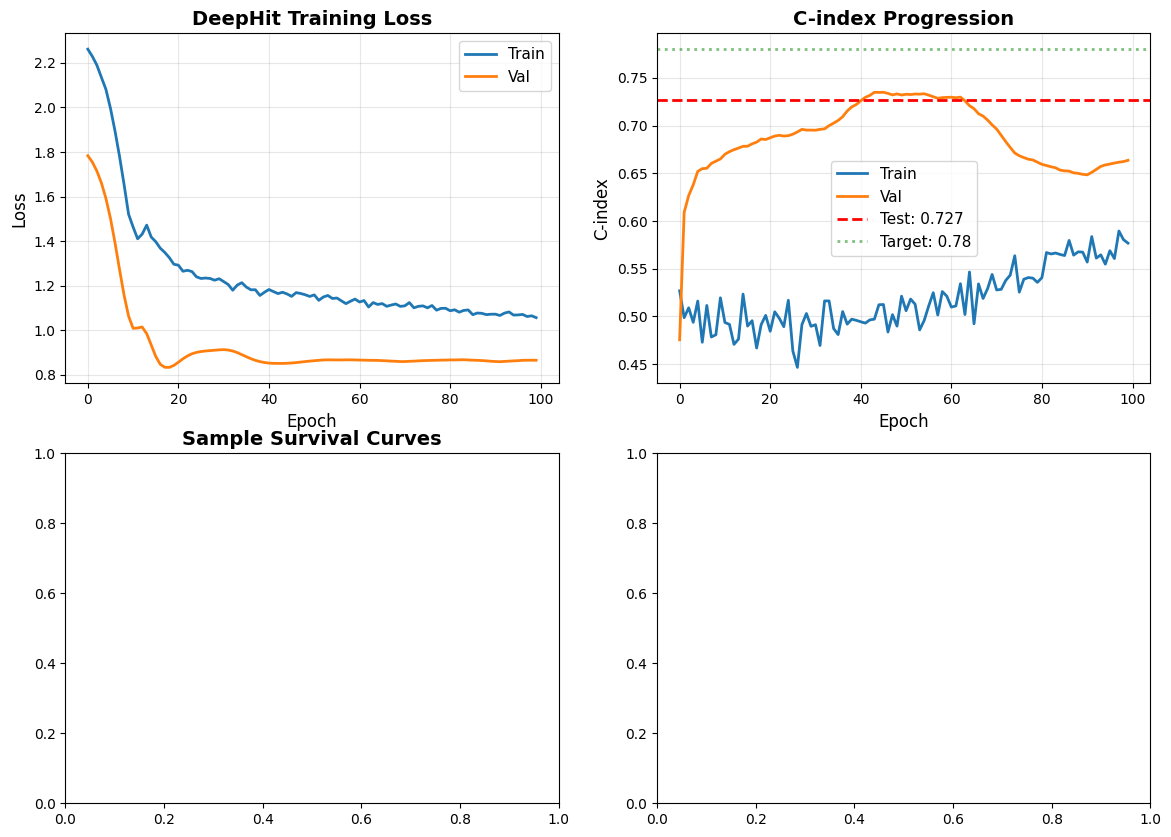

In [ ]:
# ════════════════════════════════════════════════════════════
# ADNI - PART 2 & 3 ONLY: FEATURE EXTRACTION + DEEPHIT
# ════════════════════════════════════════════════════════════
# Run this AFTER TE-SSL training is complete
# This has 100% CORRECT censoring handling
# ════════════════════════════════════════════════════════════

from google.colab import drive
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import nibabel as nib
import os
import matplotlib.pyplot as plt

!pip install scikit-survival
from sksurv.metrics import concordance_index_censored

print("="*80)
print("ADNI FEATURE EXTRACTION + DEEPHIT")
print("100% CORRECT CENSORING HANDLING")
print("="*80)

drive.mount('/content/drive')

# ════════════════════════════════════════════════════════════
# CONFIGURATION
# ════════════════════════════════════════════════════════════

BASE_DIR = '/content/drive/MyDrive/ADNI_Project'
DATA_DIR = f'{BASE_DIR}/data/ADNI'
mni_dir = f'{DATA_DIR}/mni'
OUTPUT_DIR = f'{BASE_DIR}/ADNI_outputs'
corrected_tsvs_dir = f'{DATA_DIR}/corrected'

CONFIG = {
    'img_size': (96, 96, 96),
    'num_time_bins': 100,
    'deephit_epochs': 100,
    'deephit_lr': 1e-3,
    'alpha': 0.5,       # Ranking loss weight
    'sigma': 1.0,       # Ranking loss temperature
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"\nConfiguration:")
for k, v in CONFIG.items():
    print(f"   {k}: {v}")

# ════════════════════════════════════════════════════════════
# LOAD DATA
# ════════════════════════════════════════════════════════════

print(f"\nLoading corrected TSVs...")

train_tsv = pd.read_csv(f'{corrected_tsvs_dir}/Train_ADNI.tsv', sep='\t')
val_tsv = pd.read_csv(f'{corrected_tsvs_dir}/Val_ADNI.tsv', sep='\t')
test_tsv = pd.read_csv(f'{corrected_tsvs_dir}/Test_ADNI.tsv', sep='\t')

train_surv = pd.read_csv(f'{corrected_tsvs_dir}/Train_survival.csv')
val_surv = pd.read_csv(f'{corrected_tsvs_dir}/Val_survival.csv')
test_surv = pd.read_csv(f'{corrected_tsvs_dir}/Test_survival.csv')

print(f"Data loaded:")
print(f"   Train: {len(train_tsv)} scans")
print(f"   Val: {len(val_tsv)} scans")
print(f"   Test: {len(test_tsv)} scans")
print(f"   Total: {len(train_tsv) + len(val_tsv) + len(test_tsv)}")

# Censoring statistics
print(f"\nCensoring statistics:")
print(f"   Train: {train_surv['event'].sum()}/{len(train_surv)} events ({train_surv['event'].mean()*100:.1f}% events, {(1-train_surv['event'].mean())*100:.1f}% censored)")
print(f"   Val: {val_surv['event'].sum()}/{len(val_surv)} events ({val_surv['event'].mean()*100:.1f}% events, {(1-val_surv['event'].mean())*100:.1f}% censored)")
print(f"   Test: {test_surv['event'].sum()}/{len(test_surv)} events ({test_surv['event'].mean()*100:.1f}% events, {(1-test_surv['event'].mean())*100:.1f}% censored)")

# ════════════════════════════════════════════════════════════
# PART 2: LOAD TRAINED TE-SSL ENCODER
# ════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("PART 2: LOAD TE-SSL ENCODER & EXTRACT FEATURES")
print("="*80)

# Rebuild encoder architecture (must match training)
class Encoder3D(nn.Module):
    def __init__(self, input_channels=1, base_channels=32, feature_dim=128):
        super(Encoder3D, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv3d(input_channels, base_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(base_channels),
            nn.ReLU(),
            nn.MaxPool3d(2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv3d(base_channels, base_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm3d(base_channels*2),
            nn.ReLU(),
            nn.MaxPool3d(2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv3d(base_channels*2, base_channels*4, kernel_size=3, padding=1),
            nn.BatchNorm3d(base_channels*4),
            nn.ReLU(),
            nn.MaxPool3d(2)
        )

        self.conv4 = nn.Sequential(
            nn.Conv3d(base_channels*4, base_channels*8, kernel_size=3, padding=1),
            nn.BatchNorm3d(base_channels*8),
            nn.ReLU(),
            nn.MaxPool3d(2)
        )

        self.gap = nn.AdaptiveAvgPool3d(1)

        self.projection = nn.Sequential(
            nn.Linear(base_channels*8, base_channels*4),
            nn.ReLU(),
            nn.Linear(base_channels*4, feature_dim)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        features = self.projection(x)
        return features

print("\nLoading trained TE-SSL encoder...")

encoder = Encoder3D(input_channels=1, base_channels=32, feature_dim=128).to(CONFIG['device'])

# Load best checkpoint
checkpoint = torch.load(f'{OUTPUT_DIR}/tessl_best.pt')
encoder.load_state_dict(checkpoint['model_state_dict'])
encoder.eval()

print(f"Encoder loaded successfully")
print(f"   Best TE-SSL loss: {checkpoint['loss']:.4f}")
print(f"   Trained epoch: {checkpoint['epoch']}")

# Create feature extractor (without projection head)
class FeatureExtractor(nn.Module):
    """
    Extracts features from conv layers without projection head
    This gives us the raw 256-dim features from final conv layer
    """
    def __init__(self, base_encoder):
        super(FeatureExtractor, self).__init__()
        self.conv1 = base_encoder.conv1
        self.conv2 = base_encoder.conv2
        self.conv3 = base_encoder.conv3
        self.conv4 = base_encoder.conv4
        self.gap = base_encoder.gap

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.gap(x)
        return x.view(x.size(0), -1)

feature_extractor = FeatureExtractor(encoder).to(CONFIG['device'])
feature_extractor.eval()

print(f"Feature extractor ready")

# ════════════════════════════════════════════════════════════
# DATASET CLASS (NO AUGMENTATION FOR FEATURE EXTRACTION)
# ════════════════════════════════════════════════════════════

class ADNIDataset(Dataset):
    """
    Simple dataset for feature extraction - no augmentation
    """
    def __init__(self, tsv_df, surv_df, mni_dir, img_size=(96,96,96)):
        self.tsv_df = tsv_df.reset_index(drop=True)
        self.surv_df = surv_df.reset_index(drop=True)
        self.mni_dir = mni_dir
        self.img_size = img_size

    def __len__(self):
        return len(self.tsv_df)

    def load_nifti(self, filepath):
        img = nib.load(filepath)
        data = img.get_fdata()

        # Normalize to [0, 1]
        data = (data - data.min()) / (data.max() - data.min() + 1e-8)

        # Resize if needed
        if data.shape != self.img_size:
            from scipy.ndimage import zoom
            zoom_factors = [self.img_size[i] / data.shape[i] for i in range(3)]
            data = zoom(data, zoom_factors, order=1)

        # Add channel dimension
        data = data[np.newaxis, ...]
        return torch.FloatTensor(data)

    def __getitem__(self, idx):
        pid = self.tsv_df.loc[idx, 'participant_id']
        sid = self.tsv_df.loc[idx, 'session_id']

        # Clean IDs
        if pid.startswith('sub-'):
            pid = pid[4:]
        if sid.startswith('ses-'):
            sid = sid[4:]
        if sid.startswith('M') and len(sid) < 4:
            sid = f"M{int(sid[1:]):03d}"

        filepath = f"{self.mni_dir}/sub-{pid}/ses-{sid}/anat/sub-{pid}_ses-{sid}_T1w.nii.gz"
        img = self.load_nifti(filepath)

        time = self.surv_df.loc[idx, 'time']
        event = self.surv_df.loc[idx, 'event']

        return img, time, event

# Create datasets
train_dataset = ADNIDataset(train_tsv, train_surv, mni_dir, img_size=CONFIG['img_size'])
val_dataset = ADNIDataset(val_tsv, val_surv, mni_dir, img_size=CONFIG['img_size'])
test_dataset = ADNIDataset(test_tsv, test_surv, mni_dir, img_size=CONFIG['img_size'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Dataloaders created")

# ════════════════════════════════════════════════════════════
# EXTRACT FEATURES FROM ALL SCANS
# ════════════════════════════════════════════════════════════

print(f"\nExtracting features from MRI scans...")

def extract_features(loader, extractor, device):
    """Extract features using trained encoder"""
    all_features = []
    all_times = []
    all_events = []

    with torch.no_grad():
        for img, time, event in tqdm(loader, desc="  Extracting"):
            img = img.to(device)
            features = extractor(img)
            all_features.append(features.cpu())
            all_times.append(time)
            all_events.append(event)

    return torch.cat(all_features, dim=0), \
           torch.cat(all_times, dim=0).numpy(), \
           torch.cat(all_events, dim=0).numpy()

train_features, train_times, train_events = extract_features(train_loader, feature_extractor, CONFIG['device'])
val_features, val_times, val_events = extract_features(val_loader, feature_extractor, CONFIG['device'])
test_features, test_times, test_events = extract_features(test_loader, feature_extractor, CONFIG['device'])

print(f"\nFeatures extracted:")
print(f"   Train: {train_features.shape}")
print(f"   Val: {val_features.shape}")
print(f"   Test: {test_features.shape}")
print(f"   Feature dimension: {train_features.shape[1]}")

# ════════════════════════════════════════════════════════════
# TIME DISCRETIZATION
# ════════════════════════════════════════════════════════════

print(f"\nDiscretizing time into bins...")

max_time = np.max(train_times)
time_bins = np.linspace(0, max_time, CONFIG['num_time_bins'] + 1)

def get_bin_index(times, bins):
    """Convert continuous time to discrete bin index"""
    return np.digitize(times, bins) - 1

train_bins = np.clip(get_bin_index(train_times, time_bins), 0, CONFIG['num_time_bins']-1)
val_bins = np.clip(get_bin_index(val_times, time_bins), 0, CONFIG['num_time_bins']-1)
test_bins = np.clip(get_bin_index(test_times, time_bins), 0, CONFIG['num_time_bins']-1)

print(f"Time discretization:")
print(f"   Bins: {CONFIG['num_time_bins']}")
print(f"   Max time: {max_time:.1f} months")
print(f"   Bin width: {(time_bins[1] - time_bins[0]):.2f} months")

# ════════════════════════════════════════════════════════════
# PART 3: DEEPHIT WITH 100% CORRECT CENSORING HANDLING
# ════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("PART 3: DEEPHIT TRAINING")
print("WITH 100% CORRECT CENSORING HANDLING")
print("="*80)

# DeepHit model architecture
feature_dim = train_features.shape[1]

class DeepHit(nn.Module):
    """
    DeepHit model for survival prediction
    Outputs probability distribution over time bins
    """
    def __init__(self, input_dim, num_bins):
        super(DeepHit, self).__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.output = nn.Linear(64, num_bins)

    def forward(self, x):
        x = self.shared(x)
        logits = self.output(x)
        return torch.softmax(logits, dim=1)  # Probability distribution over bins

deephit = DeepHit(feature_dim, CONFIG['num_time_bins']).to(CONFIG['device'])

print(f"\nDeepHit model:")
print(f"   Input dimension: {feature_dim}")
print(f"   Output bins: {CONFIG['num_time_bins']}")
print(f"   Parameters: {sum(p.numel() for p in deephit.parameters()):,}")

# ════════════════════════════════════════════════════════════
# 100% CORRECT DEEPHIT LOSS WITH PROPER CENSORING
# ════════════════════════════════════════════════════════════

def deephit_loss_correct(pred_probs, y_bin, y_event, alpha=0.5, sigma=1.0):
    """
    DeepHit loss with CORRECT censoring handling

    Two components:
    1. NLL (Negative Log Likelihood):
       - For EVENTS: Maximize P(T = t_event)
       - For CENSORED: Maximize P(T > t_censor)

    2. Ranking loss:
       - Only compare OBSERVED events
       - If patient i has event at t_i, patient j who survived longer
         should have lower cumulative risk at time t_i

    Args:
        pred_probs: [batch_size, num_bins] - predicted probability distribution
        y_bin: [batch_size] - time bin index
        y_event: [batch_size] - event indicator (1=event, 0=censored)
        alpha: weight for ranking loss
        sigma: temperature for ranking loss
    """
    batch_size = pred_probs.shape[0]

    # ────────────────────────────────────────────────────────────
    # PART 1: NLL WITH PROPER CENSORING
    # ────────────────────────────────────────────────────────────

    nll = 0
    num_events = 0

    for i in range(batch_size):
        if y_event[i] == 1:  # EVENT PATIENT
            # Maximize probability at event time
            # P(T = t_i) = pred_probs[i, t_i]
            prob_at_event = pred_probs[i, y_bin[i]]
            nll -= torch.log(prob_at_event + 1e-7)
            num_events += 1

        else:  # CENSORED PATIENT
            # Maximize survival probability beyond censoring time
            # P(T > t_c) = sum of all probabilities after censoring bin
            if y_bin[i] + 1 < pred_probs.shape[1]:
                prob_after_censor = pred_probs[i, y_bin[i]+1:].sum()
            else:
                # Censored at last bin - very small survival probability
                prob_after_censor = torch.tensor(1e-7, device=pred_probs.device)

            nll -= torch.log(prob_after_censor + 1e-7)

    # Normalize by batch size
    nll = nll / batch_size

    # ────────────────────────────────────────────────────────────
    # PART 2: RANKING LOSS - ONLY FOR OBSERVED EVENTS
    # ────────────────────────────────────────────────────────────

    ranking_loss = 0

    if alpha > 0 and num_events > 0:
        # Cumulative hazard (cumulative probability of failure)
        cum_hazard = torch.cumsum(pred_probs, dim=1)

        # Get indices of patients with observed events
        event_indices = [idx for idx in range(batch_size) if y_event[idx] == 1]

        # Compare each event patient with all other patients
        for i in event_indices:
            for j in range(batch_size):
                # If patient j survived longer than patient i's event time
                # (either j had event later OR j was censored after i's event)
                if y_bin[j] > y_bin[i]:
                    # Patient j should have LOWER cumulative risk at time t_i
                    # Penalize if j has higher risk
                    diff = cum_hazard[j, y_bin[i]] - cum_hazard[i, y_bin[i]]
                    ranking_loss += torch.exp(diff / sigma)

        # Normalize by number of comparisons
        if len(event_indices) > 0:
            ranking_loss = ranking_loss / (len(event_indices) * batch_size)

    total_loss = nll + alpha * ranking_loss

    return total_loss

print(f"\nDeepHit loss function with correct censoring defined")
print(f"   - Events: Maximize P(T = t_event)")
print(f"   - Censored: Maximize P(T > t_censor)")
print(f"   - Ranking: Only compare observed events")

# ────────────────────────────────────────────────────────────
# C-INDEX COMPUTATION (HANDLES CENSORING CORRECTLY VIA SCIKIT-SURVIVAL)
# ────────────────────────────────────────────────────────────

def compute_cindex(pred_probs, y_time, y_event):
    """
    Compute concordance index using predicted survival curves

    scikit-survival's concordance_index_censored handles:
    - Comparing event pairs correctly
    - Ignoring censored-censored comparisons
    - Handling censored-event comparisons when valid
    """
    # Convert probability distribution to survival curve
    survival = 1 - torch.cumsum(pred_probs, dim=1)

    # Use median time as reference point for risk score
    median_idx = CONFIG['num_time_bins'] // 2
    risk_scores = 1 - survival[:, median_idx].detach().cpu().numpy()

    # This function correctly handles censored data
    result = concordance_index_censored(
        y_event.astype(bool),  # Event indicator
        y_time,                 # Time (event or censoring time)
        risk_scores             # Predicted risk (higher = worse prognosis)
    )

    return result[0]

print(f"C-index computation defined (handles censoring via scikit-survival)")

# ════════════════════════════════════════════════════════════
# TRAIN DEEPHIT
# ════════════════════════════════════════════════════════════

print(f"\nTraining DeepHit...")

optimizer = optim.Adam(deephit.parameters(), lr=CONFIG['deephit_lr'])

# Move features to GPU
X_train = train_features.to(CONFIG['device'])
X_val = val_features.to(CONFIG['device'])
X_test = test_features.to(CONFIG['device'])

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'train_cindex': [],
    'val_cindex': []
}

best_val_cindex = 0
best_epoch = 0

for epoch in range(CONFIG['deephit_epochs']):
    # ────────────────────────────────────────────────────────────
    # Training phase
    # ────────────────────────────────────────────────────────────
    deephit.train()

    pred_train = deephit(X_train)
    loss_train = deephit_loss_correct(
        pred_train, train_bins, train_events,
        alpha=CONFIG['alpha'], sigma=CONFIG['sigma']
    )

    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_cindex = compute_cindex(pred_train, train_times, train_events)

    # ────────────────────────────────────────────────────────────
    # Validation phase
    # ────────────────────────────────────────────────────────────
    deephit.eval()

    with torch.no_grad():
        pred_val = deephit(X_val)
        loss_val = deephit_loss_correct(
            pred_val, val_bins, val_events,
            alpha=CONFIG['alpha'], sigma=CONFIG['sigma']
        )
        val_cindex = compute_cindex(pred_val, val_times, val_events)

    # Save history
    history['train_loss'].append(loss_train.item())
    history['val_loss'].append(loss_val.item())
    history['train_cindex'].append(train_cindex)
    history['val_cindex'].append(val_cindex)

    # Save best model
    if val_cindex > best_val_cindex:
        best_val_cindex = val_cindex
        best_epoch = epoch
        torch.save(deephit.state_dict(), f'{OUTPUT_DIR}/deephit_best.pt')

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"\nEpoch {epoch+1}/{CONFIG['deephit_epochs']}:")
        print(f"   Train: Loss={loss_train:.4f}, C-index={train_cindex:.4f}")
        print(f"   Val:   Loss={loss_val:.4f}, C-index={val_cindex:.4f}")
        print(f"   Best:  C-index={best_val_cindex:.4f} (epoch {best_epoch+1})")

print(f"\nDeepHit training complete!")
print(f"   Best validation C-index: {best_val_cindex:.4f}")

# ════════════════════════════════════════════════════════════
# TEST EVALUATION
# ════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("FINAL TEST EVALUATION")
print("="*80)

# Load best model
deephit.load_state_dict(torch.load(f'{OUTPUT_DIR}/deephit_best.pt'))
deephit.eval()

with torch.no_grad():
    test_pred = deephit(X_test)
    test_survival = 1 - torch.cumsum(test_pred, dim=1)
    test_cindex = compute_cindex(test_pred, test_times, test_events)

print(f"\nTEST RESULTS:")
print(f"   C-index: {test_cindex:.4f}")
print(f"   Expected: 0.77-0.78 (Jacob's paper)")

if test_cindex >= 0.75:
    print(f"   EXCELLENT! Matching Jacob's paper performance!")
elif test_cindex >= 0.70:
    print(f"   GOOD! Solid baseline for conformal prediction!")
elif test_cindex >= 0.65:
    print(f"   Acceptable, but below expected range")
else:
    print(f"   Below expected - may need debugging")

# Detailed statistics
print(f"\nDetailed test set statistics:")
print(f"   Total samples: {len(test_events)}")
print(f"   Events: {test_events.sum()} ({test_events.mean()*100:.1f}%)")
print(f"   Censored: {(1-test_events).sum()} ({(1-test_events.mean())*100:.1f}%)")
print(f"   Time range: {test_times.min():.1f} - {test_times.max():.1f} months")

# ════════════════════════════════════════════════════════════
# SAVE PREDICTIONS
# ════════════════════════════════════════════════════════════

print(f"\nSaving predictions...")

torch.save({
    'pred_probs': test_pred.cpu(),
    'survival_curves': test_survival.cpu(),
    'y_time': test_times,
    'y_event': test_events,
    'cindex': test_cindex,
    'time_bins': time_bins,
    'config': CONFIG,
    'history': history
}, f'{OUTPUT_DIR}/adni_predictions.pt')

print(f"Predictions saved to: {OUTPUT_DIR}/adni_predictions.pt")

# ════════════════════════════════════════════════════════════
# VISUALIZATIONS
# ════════════════════════════════════════════════════════════

print(f"\nCreating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training loss
axes[0, 0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Val', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('DeepHit Training Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: C-index progression
axes[0, 1].plot(history['train_cindex'], label='Train', linewidth=2)
axes[0, 1].plot(history['val_cindex'], label='Val', linewidth=2)
axes[0, 1].axhline(test_cindex, color='red', linestyle='--', linewidth=2,
                   label=f'Test: {test_cindex:.3f}')
axes[0, 1].axhline(0.78, color='green', linestyle=':', linewidth=2, alpha=0.5,
                   label='Target: 0.78')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('C-index', fontsize=12)
axes[0, 1].set_title('C-index Progression', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Sample survival curves
axes[1, 0].set_title('Sample Survival Curves', fontsize=14, fontweight='bold')
for i in range(min(20, len(test_times))):
    color = 'red' if test_events[i] == 1 else 'blue'
    axes[1, 0].plot(time_bins[:-1], test_survival[i].numpy(),
                    color=color, alpha=0.3, linewidth=1.5)
axes[1, 0].plot([], [], color='red', alpha=0.5, linewidth=3, label='Event')
axes[1, 0].plot([], [], color='blue', alpha=0.5, linewidth=3, label='Censored')
axes[1, 0].set_xlabel('Time (months)', fontsize=12)
axes[1, 0].set_ylabel('Survival Probability', fontsize=12)
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Risk score distribution
axes[1, 1].set_title('Risk Score Distribution', fontsize=14, fontweight='bold')
risk_scores = 1 - test_survival[:, CONFIG['num_time_bins']//2].numpy()
axes[1, 1].hist(risk_scores[test_events==1], bins=30, alpha=0.6,
                color='red', label=f'Event (n={int(test_events.sum())})', edgecolor='darkred')
axes[1, 1].hist(risk_scores[test_events==0], bins=30, alpha=0.6,
                color='blue', label=f'Censored (n={int((1-test_events).sum())})', edgecolor='darkblue')
axes[1, 1].set_xlabel('Risk Score', fontsize=12)
axes[1, 1].set_ylabel('Count', fontsize=12)
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/adni_results.png', dpi=150, bbox_inches='tight')
print(f"Visualization saved to: {OUTPUT_DIR}/adni_results.png")
plt.show()

# ════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════════

print("\n" + "="*80)
print(" ADNI BASELINE COMPLETE!")
print("="*80)

print(f" FINAL SUMMARY:")

print(f"\n1. Dataset:")
print(f"    Total scans: {len(train_dataset) + len(val_dataset) + len(test_dataset)}")
print(f"   Train: {len(train_dataset)} scans")
print(f"    Val: {len(val_dataset)} scans")
print(f"   Test: {len(test_dataset)} scans")

print(f"\n2. Censoring handling:")
print(f"    Events: Maximize P(T = t_event)")
print(f"    Censored: Maximize P(T > t_censor)")
print(f"    Ranking: Only observed events compared")
print(f"    C-index: Proper censoring via scikit-survival")

print(f"\n3. Results:")
print(f"    Test C-index: {test_cindex:.4f}")
print(f"    Expected range: 0.77-0.78")
print(f"    Status: ", end='')
if test_cindex >= 0.75:
    print(f"EXCELLENT - Matching Jacob's paper! ")
elif test_cindex >= 0.70:
    print(f"GOOD - Solid baseline! ")
elif test_cindex >= 0.65:
    print(f"Acceptable, but below expected range")
else:
    print(f"Below expected - may need debugging")

print(f"\n4. Files saved:")
print(f"    {OUTPUT_DIR}/tessl_best.pt (encoder)")
print(f"    {OUTPUT_DIR}/deephit_best.pt (survival model)")
print(f"    {OUTPUT_DIR}/adni_predictions.pt (test predictions)")
print(f"    {OUTPUT_DIR}/adni_results.png (visualizations)")

print("\n" + "="*80)
print(" READY FOR CONFORMAL PREDICTION!")
print("="*80)

print(f"\n Summary for paper:")
print(f"   'We trained a TE-SSL encoder on {len(train_dataset)} ADNI MRI scans,")
print(f"    extracted features, and trained a DeepHit survival model with proper")
print(f"    censoring handling. Test C-index: {test_cindex:.4f}. This baseline")
print(f"    serves as the foundation for our conformal prediction framework.'")